# LightEval CSD Accuracy and Performance Analysis

This notebook loads `RESULT_JSONL`, flattens the compact LightEval rows, and compares baseline, vanilla speculative decoding, CSD-static, and CSD-dyn.

Accuracy remains the primary table/plot, but throughput and latency are also shown as reference performance signals. Speed claims should still use the dedicated batch-size sweep results.

LCB note: LCB rows can appear in the accuracy tables while missing speculative metrics such as `spec_success_rate` and `accept_length`. Those rows are kept visible and listed in the missing-metrics table instead of being silently dropped.

In [31]:
from pathlib import Path
import json
import math
import re

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

RESULT_JSONL = Path('/home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/result.jsonl')
assert RESULT_JSONL.exists(), RESULT_JSONL
FIGURE_DIR = RESULT_JSONL.parent / 'analysis_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_JSONL

PosixPath('/home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/result.jsonl')

## Load and flatten rows

In [32]:
def load_jsonl_row(line, line_no):
    stripped = line.strip()
    if not stripped:
        return None, False
    candidate = stripped
    recovered = False
    if not candidate.startswith('{'):
        brace = candidate.find('{')
        if brace < 0:
            raise ValueError(f'Line {line_no} does not contain a JSON object: {stripped[:120]!r}')
        candidate = candidate[brace:]
        recovered = True
    try:
        return json.loads(candidate), recovered
    except json.JSONDecodeError as exc:
        raise ValueError(f'Invalid JSON on line {line_no}: {exc}; prefix={stripped[:120]!r}') from exc


def base_task_name(task):
    if not isinstance(task, str):
        return task
    return task.split('|', 1)[0]


def variant_label(mode, dynamic_update):
    if mode == 'csd':
        return 'csd-dyn' if bool(dynamic_update) else 'csd-static'
    return mode


def safe_slug(value):
    value = 'none' if value is None else str(value)
    value = re.sub(r'[^A-Za-z0-9._-]+', '-', value).strip('-_')
    return value or 'none'


def save_figure(fig, name):
    path = FIGURE_DIR / f'{safe_slug(name)}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path


def format_speedup(value):
    if pd.isna(value):
        return 'n/a'
    return f'{value:.2f}x vs baseline'


def flatten_row(row, line_no):
    other = row.get('other') or {}
    speculative = other.get('speculative') or {}
    csd = other.get('csd') or {}
    performance = other.get('performance') or {}
    spec_metrics = other.get('speculative_metrics') or {}
    server_config = other.get('server_config') or {}

    task = row.get('task') or other.get('task')
    mode = other.get('mode')
    steps = speculative.get('num_steps')
    topk = speculative.get('eagle_topk')
    draft = speculative.get('num_draft_tokens')
    freq = csd.get('freq_threshold')
    ratio = csd.get('prob_ratio')
    dynamic_update = csd.get('dynamic_update')
    shape = 'baseline' if mode == 'baseline' else f"steps{steps}_topk{topk}_draft{draft}"
    config = f"{mode}|{shape}|freq{freq}|ratio{ratio}|dyn{dynamic_update}"

    lookup_hits = row.get('csd_lookup_hit_ct')
    forced_accepts = row.get('csd_forced_accept_ct')
    verify_ct = row.get('spec_verify_ct')
    total_completion_tokens = spec_metrics.get('total_completion_tokens')
    total_prompt_tokens = spec_metrics.get('total_prompt_tokens')
    total_requests = spec_metrics.get('total_requests') or row.get('num_requests')
    avg_prompt_tokens = row.get('avg_prompt_tokens')
    avg_completion_tokens = row.get('avg_completion_tokens')
    if avg_prompt_tokens is None:
        avg_prompt_tokens = other.get('avg_prompt_tokens')
    if avg_completion_tokens is None:
        avg_completion_tokens = other.get('avg_completion_tokens')
    spec_success_rate = row.get('spec_success_rate')
    accept_length = row.get('accept_length')
    throughput = row.get('throughput')

    missing_spec_metrics = mode != 'baseline' and (pd.isna(spec_success_rate) or pd.isna(accept_length))
    missing_performance = pd.isna(throughput) or throughput == 0

    return {
        'line': line_no,
        'task': task,
        'base_task': base_task_name(task),
        'mode': mode,
        'variant': variant_label(mode, dynamic_update),
        'config': config,
        'run_tag': other.get('run_tag'),
        'accuracy': row.get('accuracy'),
        'latency_sec': row.get('latency'),
        'throughput': throughput,
        'request_throughput': performance.get('request_throughput'),
        'total_token_throughput': performance.get('total_token_throughput'),
        'num_requests': row.get('num_requests'),
        'total_requests': total_requests,
        'avg_prompt_tokens': avg_prompt_tokens,
        'avg_completion_tokens': avg_completion_tokens,
        'total_prompt_tokens': total_prompt_tokens,
        'total_completion_tokens': total_completion_tokens,
        'spec_shape': shape,
        'spec_steps': steps,
        'spec_topk': topk,
        'spec_draft_tokens': draft,
        'accept_length': accept_length,
        'aggregate_accept_length': row.get('aggregate_accept_length'),
        'spec_success_rate': spec_success_rate,
        'aggregate_spec_accept_rate': row.get('aggregate_spec_accept_rate'),
        'spec_output_token_saved_ratio': row.get('spec_output_token_saved_ratio'),
        'spec_verify_ct': verify_ct,
        'spec_draft_token_num': row.get('spec_draft_token_num'),
        'csd_enabled': row.get('csd_enabled'),
        'csd_freq_threshold': freq,
        'csd_prob_ratio': ratio,
        'csd_dynamic_update': dynamic_update,
        'csd_lookup_hit_ct': lookup_hits,
        'csd_forced_accept_ct': forced_accepts,
        'csd_delta_pair_ct': row.get('csd_delta_pair_ct'),
        'csd_force_per_hit': forced_accepts / lookup_hits if lookup_hits else None,
        'csd_force_per_verify': forced_accepts / verify_ct if verify_ct else None,
        'csd_force_per_completion_token': forced_accepts / total_completion_tokens if total_completion_tokens else None,
        'score_key': other.get('score_key'),
        'max_running_requests': other.get('max_running_requests') or server_config.get('max_running_requests'),
        'max_gen_toks': other.get('max_gen_toks'),
        'max_length': other.get('max_length'),
        'model': other.get('model'),
        'missing_spec_metrics': missing_spec_metrics,
        'missing_performance': missing_performance,
    }

rows = []
recovered_lines = []
with RESULT_JSONL.open(encoding='utf-8') as f:
    for line_no, line in enumerate(f, 1):
        row, recovered = load_jsonl_row(line, line_no)
        if row is None:
            continue
        if recovered:
            recovered_lines.append(line_no)
        rows.append(flatten_row(row, line_no))

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} rows from {RESULT_JSONL}')
if recovered_lines:
    print(f'Recovered JSON objects from non-JSON prefixes on lines: {recovered_lines}')
df.head()

Loaded 31 rows from /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/result.jsonl


,line,task,base_task,mode,variant,config,run_tag,accuracy,latency_sec,throughput,request_throughput,total_token_throughput,num_requests,total_requests,avg_prompt_tokens,avg_completion_tokens,total_prompt_tokens,total_completion_tokens,spec_shape,spec_steps,spec_topk,spec_draft_tokens,accept_length,aggregate_accept_length,spec_success_rate,aggregate_spec_accept_rate,spec_output_token_saved_ratio,spec_verify_ct,spec_draft_token_num,csd_enabled,csd_freq_threshold,csd_prob_ratio,csd_dynamic_update,csd_lookup_hit_ct,csd_forced_accept_ct,csd_delta_pair_ct,csd_force_per_hit,csd_force_per_verify,csd_force_per_completion_token,score_key,max_running_requests,max_gen_toks,max_length,model,missing_spec_metrics,missing_performance
0,1,gsm8k|0,gsm8k,baseline,baseline,baseline|baseline|freq6|ratio0.01|dynFalse,baseline_gsm8k-0_tasksgsm8k-aime25-lcb-codegeneration_v6-minerva_math500_steps5_topk3_draft15_freq6_ratio0.01,0.918878,845.617,2468.270,1.560,2586.739,1319.0,1319.0,75.951,1582.420,100179.0,2087212.0,baseline,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,False,6,0.01,False,0.0,0.0,0.0,NaN,NaN,0.0,extractive_match,48,64000,96000,/home/shared/models/Qwen/Qwen3.5-35B-A3B,False,False
1,2,aime25|0,aime25,baseline,baseline,baseline|baseline|freq6|ratio0.01|dynFalse,baseline_aime25-0_tasksgsm8k-aime25-lcb-codegeneration_v6-minerva_math500_steps5_topk3_draft15_freq6_ratio0.01,0.933333,695.585,1238.828,0.043,1249.306,30.0,30.0,242.933,28723.667,7288.0,861710.0,baseline,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,False,6,0.01,False,0.0,0.0,0.0,NaN,NaN,0.0,pass@k:k=1&n=1,48,64000,96000,/home/shared/models/Qwen/Qwen3.5-35B-A3B,False,False
2,3,lcb:codegeneration_v6|0,lcb:codegeneration_v6,baseline,baseline,baseline|baseline|freq6|ratio0.01|dynFalse,baseline_lcb-codegeneration_v6-0_tasksgsm8k-aime25-lcb-codegeneration_v6-minerva_math500_steps5_topk3_draft15_freq6_...,0.788571,260.543,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,6,0.01,False,NaN,NaN,NaN,NaN,NaN,NaN,codegen_pass@1:16,48,64000,96000,/home/shared/models/Qwen/Qwen3.5-35B-A3B,False,True
3,4,math_500|0,math_500,baseline,baseline,baseline|baseline|freq6|ratio0.01|dynFalse,baseline_math_500-0_tasksgsm8k-aime25-lcb-codegeneration_v6-minerva_math500_steps5_topk3_draft15_freq6_ratio0.01,0.854000,1886.380,2306.071,0.265,2340.874,500.0,500.0,131.304,8700.250,65652.0,4350125.0,baseline,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,False,6,0.01,False,0.0,0.0,0.0,NaN,NaN,0.0,pass@k:k=1&n=1,48,64000,96000,/home/shared/models/Qwen/Qwen3.5-35B-A3B,False,False
4,5,gsm8k|0,gsm8k,vanilla,vanilla,vanilla|steps5_topk3_draft15|freq6|ratio0.01|dynFalse,vanilla_gsm8k-0_tasksgsm8k-aime25-lcb-codegeneration_v6-minerva_math500_steps5_topk3_draft15_freq6_ratio0.01,0.921911,814.544,2469.254,1.619,2592.242,1319.0,1319.0,75.951,1524.880,100179.0,2011317.0,steps5_topk3_draft15,5.0,3.0,15.0,5.4312,5.2741,0.8548,0.8548,0.8106,381357.0,5338998.0,False,6,0.01,False,0.0,0.0,0.0,NaN,0.0,0.0,extractive_match,48,64000,96000,/home/shared/models/Qwen/Qwen3.5-35B-A3B,False,False


## Available tasks and configurations

In [33]:
display(df.groupby(['base_task', 'variant']).size().rename('rows').reset_index())

config_cols = [
    'line', 'base_task', 'variant', 'mode', 'spec_shape', 'csd_freq_threshold', 'csd_prob_ratio',
    'csd_dynamic_update', 'accuracy', 'throughput', 'spec_success_rate', 'missing_spec_metrics',
]
display(df[config_cols].sort_values(['base_task', 'line']))

,base_task,variant,rows
0,aime25,baseline,1
1,aime25,csd-dyn,2
2,aime25,csd-static,2
3,aime25,vanilla,2
4,gsm8k,baseline,1
5,gsm8k,csd-dyn,2
6,gsm8k,csd-static,2
7,gsm8k,vanilla,2
8,lcb:codegeneration_v6,baseline,2
9,lcb:codegeneration_v6,csd-dyn,2


,line,base_task,variant,mode,spec_shape,csd_freq_threshold,csd_prob_ratio,csd_dynamic_update,accuracy,throughput,spec_success_rate,missing_spec_metrics
1,2,aime25,baseline,baseline,baseline,6,0.01,False,0.933333,1238.828,0.0000,False
5,6,aime25,vanilla,vanilla,steps5_topk3_draft15,6,0.01,False,0.900000,1359.449,0.7371,False
9,10,aime25,csd-static,csd,steps5_topk3_draft15,6,0.30,False,0.933333,1475.297,0.8320,False
13,14,aime25,csd-dyn,csd,steps5_topk3_draft15,6,0.30,True,0.833333,1287.414,0.8643,False
17,18,aime25,vanilla,vanilla,steps5_topk1_draft5,6,0.01,False,0.900000,1617.761,0.5592,False
21,22,aime25,csd-static,csd,steps5_topk1_draft5,6,0.30,False,0.900000,1899.410,0.6964,False
25,26,aime25,csd-dyn,csd,steps5_topk1_draft5,6,0.30,True,0.800000,1659.405,0.7392,False
0,1,gsm8k,baseline,baseline,baseline,6,0.01,False,0.918878,2468.270,0.0000,False
4,5,gsm8k,vanilla,vanilla,steps5_topk3_draft15,6,0.01,False,0.921911,2469.254,0.8548,False
8,9,gsm8k,csd-static,csd,steps5_topk3_draft15,6,0.30,False,0.914329,2038.694,0.8958,False


## Main table

In [34]:
main_cols = [
    'line', 'base_task', 'variant', 'spec_shape', 'csd_freq_threshold', 'csd_prob_ratio',
    'accuracy', 'throughput', 'request_throughput', 'total_token_throughput', 'latency_sec', 'num_requests',
    'accept_length', 'spec_success_rate', 'spec_output_token_saved_ratio',
    'csd_force_per_hit', 'csd_forced_accept_ct', 'csd_lookup_hit_ct', 'missing_spec_metrics',
]
main_table = df[main_cols].copy().sort_values(['base_task', 'variant', 'spec_shape', 'csd_prob_ratio', 'line'])
main_format = {
    'accuracy': '{:.6f}',
    'throughput': '{:.1f}',
    'request_throughput': '{:.3f}',
    'total_token_throughput': '{:.1f}',
    'latency_sec': '{:.1f}',
    'num_requests': '{:.0f}',
    'accept_length': '{:.4f}',
    'spec_success_rate': '{:.4f}',
    'spec_output_token_saved_ratio': '{:.4f}',
    'csd_force_per_hit': '{:.4f}',
    'csd_forced_accept_ct': '{:.0f}',
    'csd_lookup_hit_ct': '{:.0f}',
}

baseline_main = main_table[main_table['variant'] == 'baseline']
if not baseline_main.empty:
    print('Baseline')
    display(baseline_main.style.format(main_format, na_rep=''))

for spec_shape, sub in main_table[main_table['variant'] != 'baseline'].groupby('spec_shape', sort=True):
    print(f'Main table for spec_shape={spec_shape}')
    display(sub.style.format(main_format, na_rep=''))

Baseline


,line,base_task,variant,spec_shape,csd_freq_threshold,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,latency_sec,num_requests,accept_length,spec_success_rate,spec_output_token_saved_ratio,csd_force_per_hit,csd_forced_accept_ct,csd_lookup_hit_ct,missing_spec_metrics
1,2,aime25,baseline,baseline,6,0.010000,0.933333,1238.8,0.043,1249.3,695.6,30,0.0000,0.0000,0.0000,,0,0,False
0,1,gsm8k,baseline,baseline,6,0.010000,0.918878,2468.3,1.560,2586.7,845.6,1319,0.0000,0.0000,0.0000,,0,0,False
2,3,lcb:codegeneration_v6,baseline,baseline,6,0.010000,0.788571,0.0,0.000,0.0,260.5,,,,,,,,False
28,30,lcb:codegeneration_v6,baseline,baseline,6,0.010000,0.788571,1588.6,0.052,1619.9,3337.3,175,0.0000,0.0000,0.0000,,0,0,False
3,4,math_500,baseline,baseline,6,0.010000,0.854000,2306.1,0.265,2340.9,1886.4,500,0.0000,0.0000,0.0000,,0,0,False


Main table for spec_shape=steps5_topk1_draft5


,line,base_task,variant,spec_shape,csd_freq_threshold,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,latency_sec,num_requests,accept_length,spec_success_rate,spec_output_token_saved_ratio,csd_force_per_hit,csd_forced_accept_ct,csd_lookup_hit_ct,missing_spec_metrics
25,26,aime25,csd-dyn,steps5_topk1_draft5,6,0.300000,0.800000,1659.4,0.059,1673.6,512.5,30,4.6288,0.7392,0.7871,0.6020,898334,1492173,False
21,22,aime25,csd-static,steps5_topk1_draft5,6,0.300000,0.900000,1899.4,0.073,1917.0,413.4,30,4.4712,0.6964,0.7769,0.5941,825727,1389765,False
17,18,aime25,vanilla,steps5_topk1_draft5,6,0.010000,0.900000,1617.8,0.062,1632.8,486.1,30,3.8298,0.5592,0.7366,,0,0,False
24,25,gsm8k,csd-dyn,steps5_topk1_draft5,6,0.300000,0.920394,2348.1,1.411,2455.3,934.6,1319,4.9453,0.7795,0.7960,0.3777,30771676,81464417,False
20,21,gsm8k,csd-static,steps5_topk1_draft5,6,0.300000,0.915845,2640.7,1.482,2753.3,889.9,1319,4.8864,0.7839,0.7969,0.3721,24838336,66750323,False
16,17,gsm8k,vanilla,steps5_topk1_draft5,6,0.010000,0.922669,2670.6,1.551,2788.4,850.4,1319,4.7058,0.7267,0.7843,,0,0,False
26,27,lcb:codegeneration_v6,csd-dyn,steps5_topk1_draft5,6,0.300000,0.645714,0.0,0.000,0.0,245.6,,,,,,,,True
22,23,lcb:codegeneration_v6,csd-static,steps5_topk1_draft5,6,0.300000,0.714286,0.0,0.000,0.0,250.5,,,,,,,,True
18,19,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,6,0.010000,0.720000,0.0,0.000,0.0,285.0,,,,,,,,True
30,32,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,6,0.010000,0.720000,1952.8,0.064,1991.1,2721.2,175,3.4087,0.4721,0.7024,,0,0,False


Main table for spec_shape=steps5_topk3_draft15


,line,base_task,variant,spec_shape,csd_freq_threshold,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,latency_sec,num_requests,accept_length,spec_success_rate,spec_output_token_saved_ratio,csd_force_per_hit,csd_forced_accept_ct,csd_lookup_hit_ct,missing_spec_metrics
13,14,aime25,csd-dyn,steps5_topk3_draft15,6,0.300000,0.833333,1287.4,0.046,1298.6,654.2,30,5.2531,0.8643,0.8121,0.5342,933671,1747915,False
9,10,aime25,csd-static,steps5_topk3_draft15,6,0.300000,0.933333,1475.3,0.057,1489.1,526.6,30,5.1347,0.8320,0.8062,0.5113,807645,1579740,False
5,6,aime25,vanilla,steps5_topk3_draft15,6,0.010000,0.900000,1359.4,0.047,1370.9,635.1,30,4.6888,0.7371,0.7866,,0,0,False
12,13,gsm8k,csd-dyn,steps5_topk3_draft15,6,0.300000,0.930250,1866.4,1.090,1949.2,1210.6,1319,5.5477,0.9011,0.8185,0.3303,34082049,103178657,False
8,9,gsm8k,csd-static,steps5_topk3_draft15,6,0.300000,0.914329,2038.7,1.196,2129.5,1103.1,1319,5.5221,0.8958,0.8176,0.3267,26736332,81842472,False
4,5,gsm8k,vanilla,steps5_topk3_draft15,6,0.010000,0.921911,2469.3,1.619,2592.2,814.5,1319,5.4312,0.8548,0.8106,,0,0,False
14,15,lcb:codegeneration_v6,csd-dyn,steps5_topk3_draft15,6,0.300000,0.645714,0.0,0.000,0.0,257.0,,,,,,,,True
10,11,lcb:codegeneration_v6,csd-static,steps5_topk3_draft15,6,0.300000,0.720000,0.0,0.000,0.0,327.8,,,,,,,,True
6,7,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,6,0.010000,0.742857,0.0,0.000,0.0,284.9,,,,,,,,True
29,31,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,6,0.010000,0.742857,1498.0,0.050,1527.7,3508.4,175,4.3174,0.6579,0.7669,,0,0,False


## Accuracy comparison against baseline and vanilla

`accuracy_delta_vs_baseline` uses the baseline row for the same task. `accuracy_delta_vs_vanilla` uses the vanilla speculative row for the same task and speculative shape.

Throughput columns are kept for reference only; speed conclusions should come from the dedicated speed benchmark. The comparison tables are split by speculative shape.

In [35]:
baseline = (
    df[df['mode'] == 'baseline']
    .sort_values('line')
    .drop_duplicates('base_task', keep='last')
    .set_index('base_task')
)
vanilla = (
    df[df['mode'] == 'vanilla']
    .sort_values('line')
    .drop_duplicates(['base_task', 'spec_shape'], keep='last')
    .set_index(['base_task', 'spec_shape'])
)

cmp_df = df.copy()
cmp_df['baseline_accuracy'] = cmp_df['base_task'].map(baseline['accuracy'])
cmp_df['baseline_throughput'] = cmp_df['base_task'].map(baseline['throughput'])
cmp_df['accuracy_delta_vs_baseline'] = cmp_df['accuracy'] - cmp_df['baseline_accuracy']
baseline_throughput_safe = cmp_df['baseline_throughput'].mask(cmp_df['baseline_throughput'] == 0)
cmp_df['throughput_speedup_vs_baseline'] = cmp_df['throughput'] / baseline_throughput_safe
cmp_df['throughput_vs_baseline_text'] = cmp_df.apply(
    lambda row: 'baseline' if row['variant'] == 'baseline' else format_speedup(row['throughput_speedup_vs_baseline']),
    axis=1,
)


def lookup_vanilla(row, col):
    key = (row['base_task'], row['spec_shape'])
    if key not in vanilla.index:
        return None
    return vanilla.loc[key, col]

cmp_df['vanilla_accuracy'] = cmp_df.apply(lambda row: lookup_vanilla(row, 'accuracy'), axis=1)
cmp_df['vanilla_throughput'] = cmp_df.apply(lambda row: lookup_vanilla(row, 'throughput'), axis=1)
cmp_df['accuracy_delta_vs_vanilla'] = cmp_df['accuracy'] - cmp_df['vanilla_accuracy']
vanilla_throughput_safe = cmp_df['vanilla_throughput'].mask(cmp_df['vanilla_throughput'] == 0)
cmp_df['throughput_speedup_vs_vanilla'] = cmp_df['throughput'] / vanilla_throughput_safe

compare_cols = [
    'line', 'base_task', 'variant', 'spec_shape', 'csd_prob_ratio',
    'accuracy', 'baseline_accuracy', 'accuracy_delta_vs_baseline',
    'vanilla_accuracy', 'accuracy_delta_vs_vanilla',
    'throughput', 'throughput_vs_baseline_text', 'throughput_speedup_vs_baseline', 'throughput_speedup_vs_vanilla',
    'spec_success_rate', 'csd_force_per_hit', 'missing_spec_metrics',
]
compare_table = cmp_df[compare_cols].sort_values(['base_task', 'variant', 'spec_shape', 'csd_prob_ratio', 'line'])
compare_format = {
    'accuracy': '{:.6f}',
    'baseline_accuracy': '{:.6f}',
    'accuracy_delta_vs_baseline': '{:+.6f}',
    'vanilla_accuracy': '{:.6f}',
    'accuracy_delta_vs_vanilla': '{:+.6f}',
    'throughput': '{:.1f}',
    'throughput_speedup_vs_baseline': '{:.2f}x',
    'throughput_speedup_vs_vanilla': '{:.2f}x',
    'spec_success_rate': '{:.4f}',
    'csd_force_per_hit': '{:.4f}',
}

baseline_compare = compare_table[compare_table['variant'] == 'baseline']
if not baseline_compare.empty:
    print('Baseline')
    display(baseline_compare.style.format(compare_format, na_rep=''))

for spec_shape, sub in compare_table[compare_table['variant'] != 'baseline'].groupby('spec_shape', sort=True):
    print(f'Comparison table for spec_shape={spec_shape}')
    display(sub.style.format(compare_format, na_rep=''))

Baseline


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,baseline_accuracy,accuracy_delta_vs_baseline,vanilla_accuracy,accuracy_delta_vs_vanilla,throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,spec_success_rate,csd_force_per_hit,missing_spec_metrics
1,2,aime25,baseline,baseline,0.010000,0.933333,0.933333,+0.000000,,,1238.8,baseline,1.00x,,0.0000,,False
0,1,gsm8k,baseline,baseline,0.010000,0.918878,0.918878,+0.000000,,,2468.3,baseline,1.00x,,0.0000,,False
2,3,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,0.788571,+0.000000,,,0.0,baseline,0.00x,,,,False
28,30,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,0.788571,+0.000000,,,1588.6,baseline,1.00x,,0.0000,,False
3,4,math_500,baseline,baseline,0.010000,0.854000,0.854000,+0.000000,,,2306.1,baseline,1.00x,,0.0000,,False


Comparison table for spec_shape=steps5_topk1_draft5


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,baseline_accuracy,accuracy_delta_vs_baseline,vanilla_accuracy,accuracy_delta_vs_vanilla,throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,spec_success_rate,csd_force_per_hit,missing_spec_metrics
25,26,aime25,csd-dyn,steps5_topk1_draft5,0.300000,0.800000,0.933333,-0.133333,0.900000,-0.100000,1659.4,1.34x vs baseline,1.34x,1.03x,0.7392,0.6020,False
21,22,aime25,csd-static,steps5_topk1_draft5,0.300000,0.900000,0.933333,-0.033333,0.900000,+0.000000,1899.4,1.53x vs baseline,1.53x,1.17x,0.6964,0.5941,False
17,18,aime25,vanilla,steps5_topk1_draft5,0.010000,0.900000,0.933333,-0.033333,0.900000,+0.000000,1617.8,1.31x vs baseline,1.31x,1.00x,0.5592,,False
24,25,gsm8k,csd-dyn,steps5_topk1_draft5,0.300000,0.920394,0.918878,+0.001516,0.922669,-0.002275,2348.1,0.95x vs baseline,0.95x,0.88x,0.7795,0.3777,False
20,21,gsm8k,csd-static,steps5_topk1_draft5,0.300000,0.915845,0.918878,-0.003033,0.922669,-0.006824,2640.7,1.07x vs baseline,1.07x,0.99x,0.7839,0.3721,False
16,17,gsm8k,vanilla,steps5_topk1_draft5,0.010000,0.922669,0.918878,+0.003791,0.922669,+0.000000,2670.6,1.08x vs baseline,1.08x,1.00x,0.7267,,False
26,27,lcb:codegeneration_v6,csd-dyn,steps5_topk1_draft5,0.300000,0.645714,0.788571,-0.142857,0.720000,-0.074286,0.0,0.00x vs baseline,0.00x,0.00x,,,True
22,23,lcb:codegeneration_v6,csd-static,steps5_topk1_draft5,0.300000,0.714286,0.788571,-0.074285,0.720000,-0.005714,0.0,0.00x vs baseline,0.00x,0.00x,,,True
18,19,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.010000,0.720000,0.788571,-0.068571,0.720000,+0.000000,0.0,0.00x vs baseline,0.00x,0.00x,,,True
30,32,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.010000,0.720000,0.788571,-0.068571,0.720000,+0.000000,1952.8,1.23x vs baseline,1.23x,1.00x,0.4721,,False


Comparison table for spec_shape=steps5_topk3_draft15


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,baseline_accuracy,accuracy_delta_vs_baseline,vanilla_accuracy,accuracy_delta_vs_vanilla,throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,spec_success_rate,csd_force_per_hit,missing_spec_metrics
13,14,aime25,csd-dyn,steps5_topk3_draft15,0.300000,0.833333,0.933333,-0.100000,0.900000,-0.066667,1287.4,1.04x vs baseline,1.04x,0.95x,0.8643,0.5342,False
9,10,aime25,csd-static,steps5_topk3_draft15,0.300000,0.933333,0.933333,+0.000000,0.900000,+0.033333,1475.3,1.19x vs baseline,1.19x,1.09x,0.8320,0.5113,False
5,6,aime25,vanilla,steps5_topk3_draft15,0.010000,0.900000,0.933333,-0.033333,0.900000,+0.000000,1359.4,1.10x vs baseline,1.10x,1.00x,0.7371,,False
12,13,gsm8k,csd-dyn,steps5_topk3_draft15,0.300000,0.930250,0.918878,+0.011372,0.921911,+0.008339,1866.4,0.76x vs baseline,0.76x,0.76x,0.9011,0.3303,False
8,9,gsm8k,csd-static,steps5_topk3_draft15,0.300000,0.914329,0.918878,-0.004549,0.921911,-0.007582,2038.7,0.83x vs baseline,0.83x,0.83x,0.8958,0.3267,False
4,5,gsm8k,vanilla,steps5_topk3_draft15,0.010000,0.921911,0.918878,+0.003033,0.921911,+0.000000,2469.3,1.00x vs baseline,1.00x,1.00x,0.8548,,False
14,15,lcb:codegeneration_v6,csd-dyn,steps5_topk3_draft15,0.300000,0.645714,0.788571,-0.142857,0.742857,-0.097143,0.0,0.00x vs baseline,0.00x,0.00x,,,True
10,11,lcb:codegeneration_v6,csd-static,steps5_topk3_draft15,0.300000,0.720000,0.788571,-0.068571,0.742857,-0.022857,0.0,0.00x vs baseline,0.00x,0.00x,,,True
6,7,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,0.788571,-0.045714,0.742857,+0.000000,0.0,0.00x vs baseline,0.00x,0.00x,,,True
29,31,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,0.788571,-0.045714,0.742857,+0.000000,1498.0,0.94x vs baseline,0.94x,1.00x,0.6579,,False


## Best rows by task

The first table ranks by accuracy; the second ranks by throughput.

In [36]:
rank_cols = ['base_task', 'variant', 'spec_shape', 'csd_prob_ratio', 'accuracy', 'throughput', 'latency_sec', 'spec_success_rate', 'line']
best_accuracy = cmp_df.sort_values(['base_task', 'accuracy', 'throughput'], ascending=[True, False, False]).groupby('base_task').head(3)[rank_cols]
best_throughput = cmp_df.sort_values(['base_task', 'throughput', 'accuracy'], ascending=[True, False, False]).groupby('base_task').head(3)[rank_cols]
display(best_accuracy.style.format({'accuracy': '{:.6f}', 'throughput': '{:.1f}', 'latency_sec': '{:.1f}', 'spec_success_rate': '{:.4f}'}, na_rep=''))
display(best_throughput.style.format({'accuracy': '{:.6f}', 'throughput': '{:.1f}', 'latency_sec': '{:.1f}', 'spec_success_rate': '{:.4f}'}, na_rep=''))

,base_task,variant,spec_shape,csd_prob_ratio,accuracy,throughput,latency_sec,spec_success_rate,line
9,aime25,csd-static,steps5_topk3_draft15,0.300000,0.933333,1475.3,526.6,0.8320,10
1,aime25,baseline,baseline,0.010000,0.933333,1238.8,695.6,0.0000,2
21,aime25,csd-static,steps5_topk1_draft5,0.300000,0.900000,1899.4,413.4,0.6964,22
12,gsm8k,csd-dyn,steps5_topk3_draft15,0.300000,0.930250,1866.4,1210.6,0.9011,13
16,gsm8k,vanilla,steps5_topk1_draft5,0.010000,0.922669,2670.6,850.4,0.7267,17
4,gsm8k,vanilla,steps5_topk3_draft15,0.010000,0.921911,2469.3,814.5,0.8548,5
28,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,1588.6,3337.3,0.0000,30
2,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,0.0,260.5,,3
29,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,1498.0,3508.4,0.6579,31
3,math_500,baseline,baseline,0.010000,0.854000,2306.1,1886.4,0.0000,4


,base_task,variant,spec_shape,csd_prob_ratio,accuracy,throughput,latency_sec,spec_success_rate,line
21,aime25,csd-static,steps5_topk1_draft5,0.300000,0.900000,1899.4,413.4,0.6964,22
25,aime25,csd-dyn,steps5_topk1_draft5,0.300000,0.800000,1659.4,512.5,0.7392,26
17,aime25,vanilla,steps5_topk1_draft5,0.010000,0.900000,1617.8,486.1,0.5592,18
16,gsm8k,vanilla,steps5_topk1_draft5,0.010000,0.922669,2670.6,850.4,0.7267,17
20,gsm8k,csd-static,steps5_topk1_draft5,0.300000,0.915845,2640.7,889.9,0.7839,21
4,gsm8k,vanilla,steps5_topk3_draft15,0.010000,0.921911,2469.3,814.5,0.8548,5
30,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.010000,0.720000,1952.8,2721.2,0.4721,32
28,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,1588.6,3337.3,0.0000,30
29,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,1498.0,3508.4,0.6579,31
23,math_500,csd-static,steps5_topk1_draft5,0.300000,0.834000,3218.1,1176.1,0.6978,24


## Per-dataset accuracy plots

Each dataset gets its own horizontal chart so labels stay readable. Bars are colored by mode, exact accuracy is shown as a percent, and the dashed line marks the baseline accuracy for that dataset.

Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/accuracy_gsm8k.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/accuracy_aime25.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/accuracy_lcb-codegeneration_v6.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/accuracy_math_500.png


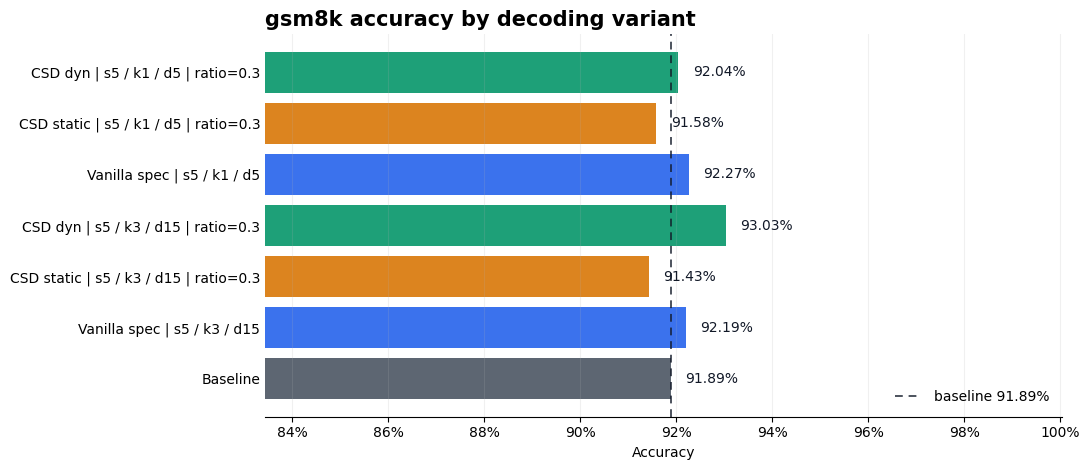

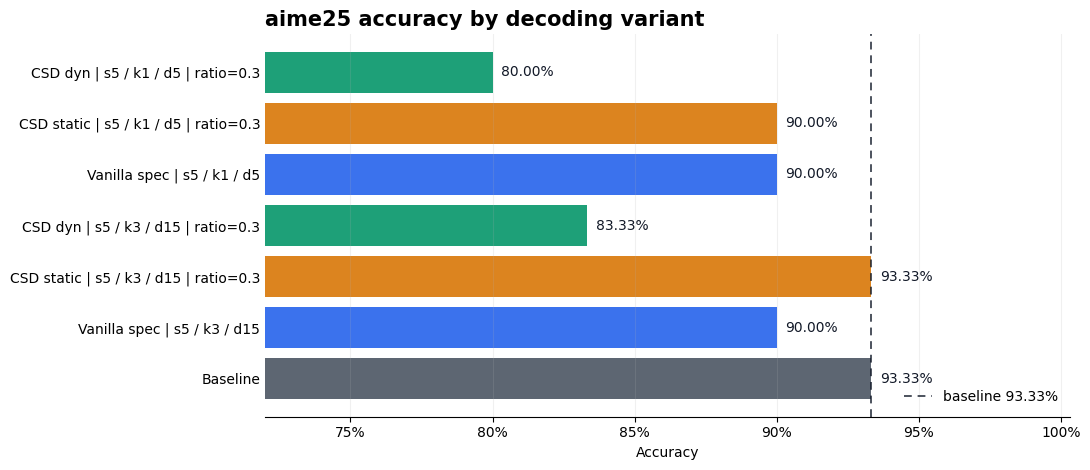

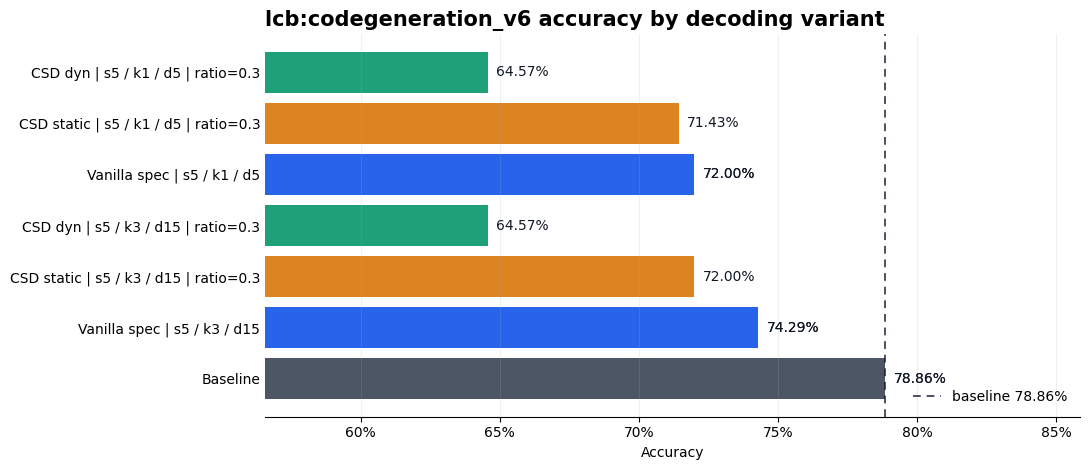

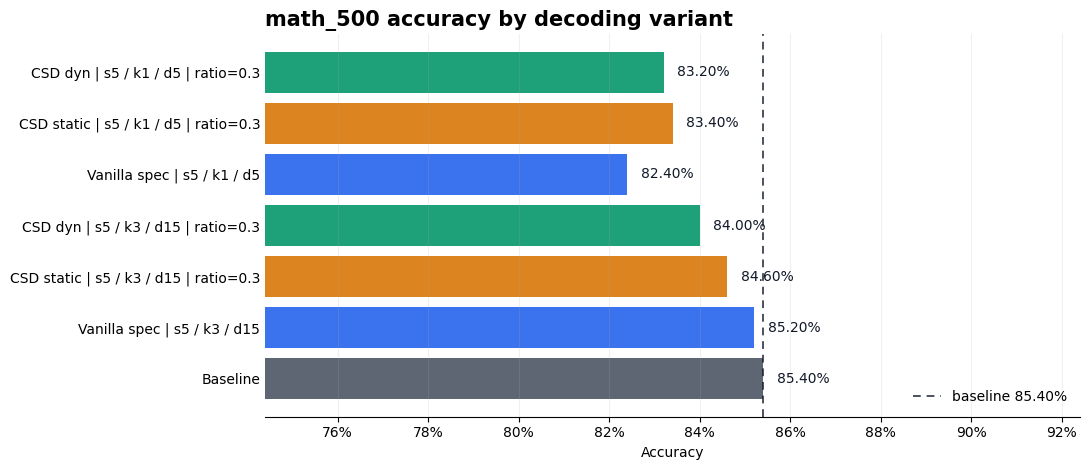

In [37]:
plot_df = cmp_df.copy()

VARIANT_COLORS = {
    'baseline': '#4b5563',
    'vanilla': '#2563eb',
    'csd-static': '#d97706',
    'csd-dyn': '#059669',
}
VARIANT_LABELS = {
    'baseline': 'Baseline',
    'vanilla': 'Vanilla spec',
    'csd-static': 'CSD static',
    'csd-dyn': 'CSD dyn',
}


def pretty_spec_shape(spec_shape):
    if not isinstance(spec_shape, str) or spec_shape == 'baseline':
        return 'baseline'
    return spec_shape.replace('steps', 's').replace('_topk', ' / k').replace('_draft', ' / d')


def pretty_config_label(row):
    variant = row['variant']
    if variant == 'baseline':
        return 'Baseline'
    label = f"{VARIANT_LABELS.get(variant, variant)} | {pretty_spec_shape(row['spec_shape'])}"
    if row['mode'] == 'csd':
        label += f" | ratio={row['csd_prob_ratio']:g}"
    return label

plot_df['plot_label'] = plot_df.apply(pretty_config_label, axis=1)
plot_df['variant_label'] = plot_df['variant'].map(VARIANT_LABELS).fillna(plot_df['variant'])

task_order = list(plot_df['base_task'].dropna().unique())
for task in task_order:
    sub = plot_df[plot_df['base_task'] == task].sort_values('line')
    fig, ax = plt.subplots(figsize=(11, 4.8))
    colors = [VARIANT_COLORS.get(variant, '#6b7280') for variant in sub['variant']]
    bars = ax.barh(sub['plot_label'], sub['accuracy'], color=colors, alpha=0.9)

    baseline_value = sub.loc[sub['variant'] == 'baseline', 'accuracy']
    if not baseline_value.empty:
        baseline_acc = baseline_value.iloc[-1]
        ax.axvline(
            baseline_acc,
            linestyle=(0, (4, 3)),
            linewidth=1.4,
            color='#111827',
            alpha=0.75,
            label=f'baseline {baseline_acc:.2%}',
        )

    for bar, value in zip(bars, sub['accuracy']):
        if pd.isna(value):
            continue
        ax.text(
            value + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.2%}',
            va='center',
            ha='left',
            fontsize=10,
            color='#111827',
        )

    xmin = max(0, sub['accuracy'].min() - 0.08)
    xmax = min(1.03, sub['accuracy'].max() + 0.07)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f'{task} accuracy by decoding variant', fontsize=15, fontweight='bold', loc='left')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='x', alpha=0.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    if not baseline_value.empty:
        ax.legend(frameon=False, loc='lower right')
    plt.tight_layout()
    save_figure(fig, f'accuracy_{task}')

## Throughput reference plots

These plots show the output-token throughput fields already written in the compact LightEval rows. Non-baseline rows are annotated with their speedup relative to the baseline row for the same task. LCB rows with `throughput=0.0` are intentionally kept visible; they indicate that the compact row did not capture usable decode throughput/speculative metrics for those runs, not that LCB should be removed from the accuracy analysis.

Baseline performance rows


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,missing_performance
1,2,aime25,baseline,baseline,0.010000,0.933333,1238.8,0.043,1249.3,baseline,1.00x,,False
0,1,gsm8k,baseline,baseline,0.010000,0.918878,2468.3,1.560,2586.7,baseline,1.00x,,False
2,3,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,0.0,0.000,0.0,baseline,0.00x,,True
28,30,lcb:codegeneration_v6,baseline,baseline,0.010000,0.788571,1588.6,0.052,1619.9,baseline,1.00x,,False
3,4,math_500,baseline,baseline,0.010000,0.854000,2306.1,0.265,2340.9,baseline,1.00x,,False


Performance table for spec_shape=steps5_topk1_draft5


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,missing_performance
25,26,aime25,csd-dyn,steps5_topk1_draft5,0.300000,0.800000,1659.4,0.059,1673.6,1.34x vs baseline,1.34x,1.03x,False
21,22,aime25,csd-static,steps5_topk1_draft5,0.300000,0.900000,1899.4,0.073,1917.0,1.53x vs baseline,1.53x,1.17x,False
17,18,aime25,vanilla,steps5_topk1_draft5,0.010000,0.900000,1617.8,0.062,1632.8,1.31x vs baseline,1.31x,1.00x,False
24,25,gsm8k,csd-dyn,steps5_topk1_draft5,0.300000,0.920394,2348.1,1.411,2455.3,0.95x vs baseline,0.95x,0.88x,False
20,21,gsm8k,csd-static,steps5_topk1_draft5,0.300000,0.915845,2640.7,1.482,2753.3,1.07x vs baseline,1.07x,0.99x,False
16,17,gsm8k,vanilla,steps5_topk1_draft5,0.010000,0.922669,2670.6,1.551,2788.4,1.08x vs baseline,1.08x,1.00x,False
26,27,lcb:codegeneration_v6,csd-dyn,steps5_topk1_draft5,0.300000,0.645714,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
22,23,lcb:codegeneration_v6,csd-static,steps5_topk1_draft5,0.300000,0.714286,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
18,19,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.010000,0.720000,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
30,32,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.010000,0.720000,1952.8,0.064,1991.1,1.23x vs baseline,1.23x,1.00x,False


Performance table for spec_shape=steps5_topk3_draft15


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,throughput,request_throughput,total_token_throughput,throughput_vs_baseline_text,throughput_speedup_vs_baseline,throughput_speedup_vs_vanilla,missing_performance
13,14,aime25,csd-dyn,steps5_topk3_draft15,0.300000,0.833333,1287.4,0.046,1298.6,1.04x vs baseline,1.04x,0.95x,False
9,10,aime25,csd-static,steps5_topk3_draft15,0.300000,0.933333,1475.3,0.057,1489.1,1.19x vs baseline,1.19x,1.09x,False
5,6,aime25,vanilla,steps5_topk3_draft15,0.010000,0.900000,1359.4,0.047,1370.9,1.10x vs baseline,1.10x,1.00x,False
12,13,gsm8k,csd-dyn,steps5_topk3_draft15,0.300000,0.930250,1866.4,1.090,1949.2,0.76x vs baseline,0.76x,0.76x,False
8,9,gsm8k,csd-static,steps5_topk3_draft15,0.300000,0.914329,2038.7,1.196,2129.5,0.83x vs baseline,0.83x,0.83x,False
4,5,gsm8k,vanilla,steps5_topk3_draft15,0.010000,0.921911,2469.3,1.619,2592.2,1.00x vs baseline,1.00x,1.00x,False
14,15,lcb:codegeneration_v6,csd-dyn,steps5_topk3_draft15,0.300000,0.645714,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
10,11,lcb:codegeneration_v6,csd-static,steps5_topk3_draft15,0.300000,0.720000,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
6,7,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,0.0,0.000,0.0,0.00x vs baseline,0.00x,0.00x,True
29,31,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.010000,0.742857,1498.0,0.050,1527.7,0.94x vs baseline,0.94x,1.00x,False


Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/throughput_gsm8k.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/throughput_aime25.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/throughput_lcb-codegeneration_v6.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/throughput_math_500.png


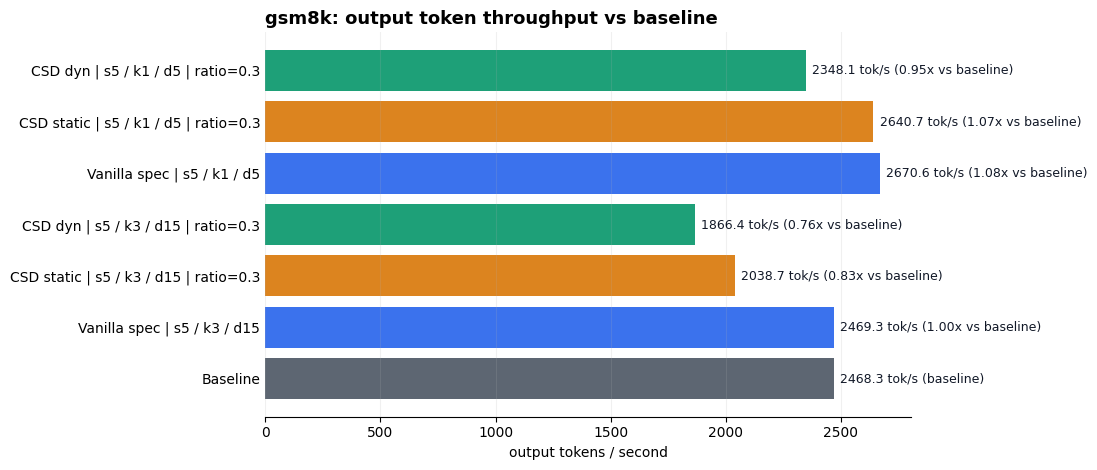

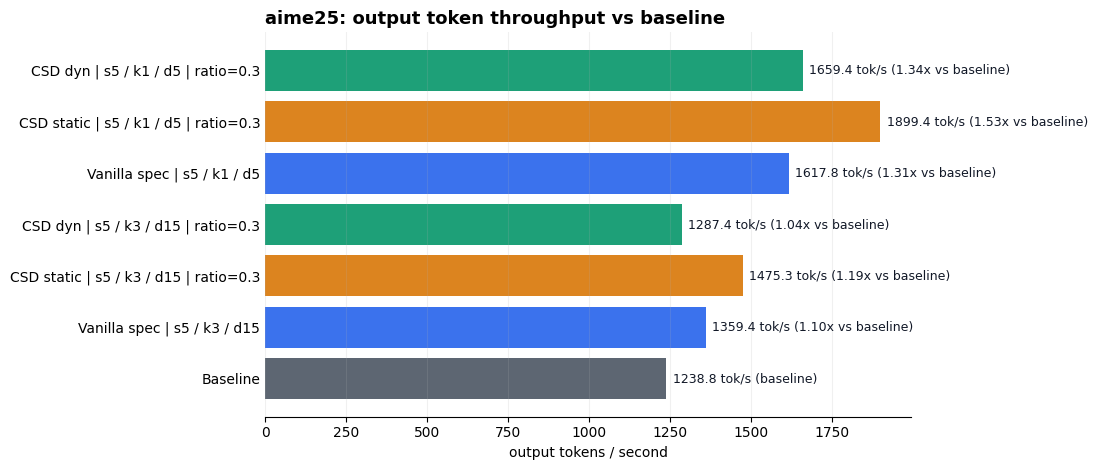

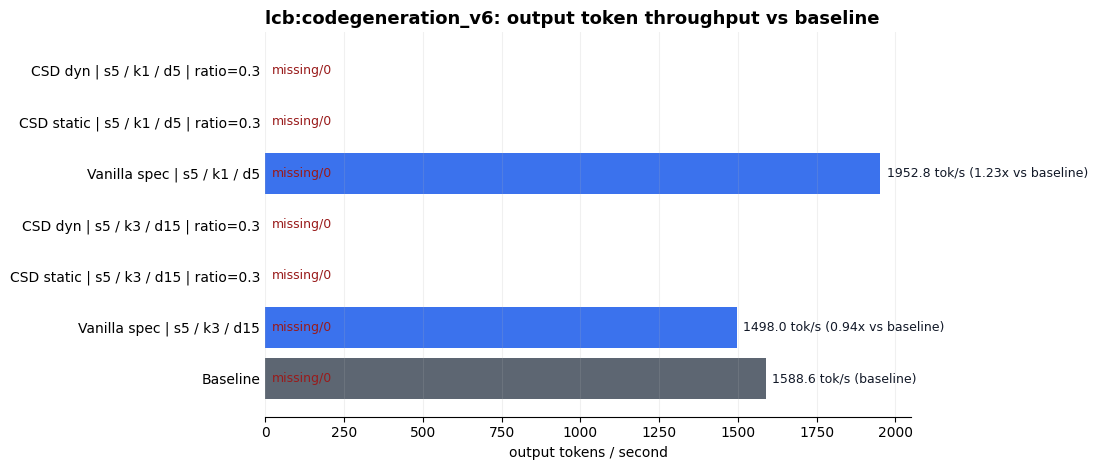

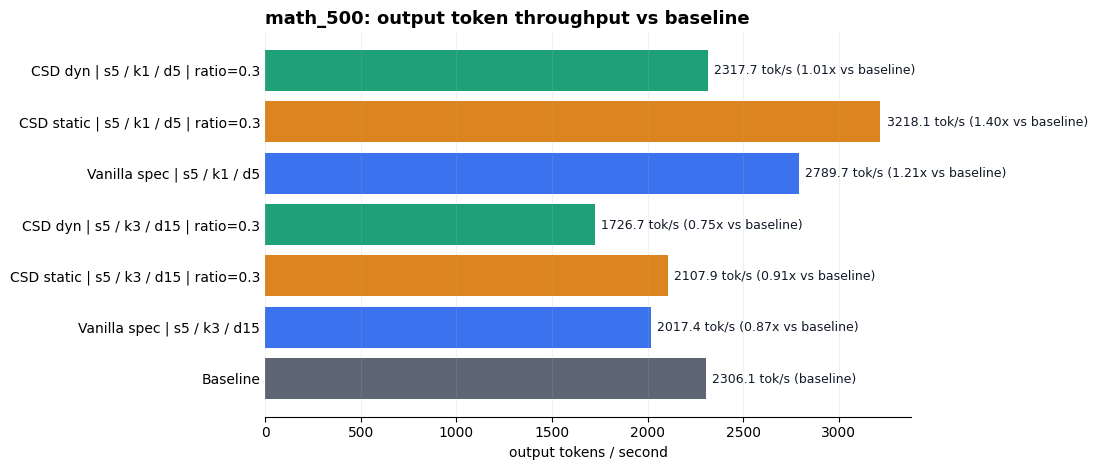

In [38]:
perf_cols = [
    'line', 'base_task', 'variant', 'spec_shape', 'csd_prob_ratio', 'accuracy',
    'throughput', 'request_throughput', 'total_token_throughput',
    'throughput_vs_baseline_text', 'throughput_speedup_vs_baseline', 'throughput_speedup_vs_vanilla', 'missing_performance',
]
perf_table = cmp_df[perf_cols].copy().sort_values(['base_task', 'spec_shape', 'variant', 'csd_prob_ratio', 'line'])
perf_format = {
    'accuracy': '{:.6f}',
    'throughput': '{:.1f}',
    'request_throughput': '{:.3f}',
    'total_token_throughput': '{:.1f}',
    'throughput_speedup_vs_baseline': '{:.2f}x',
    'throughput_speedup_vs_vanilla': '{:.2f}x',
}

baseline_perf = perf_table[perf_table['variant'] == 'baseline']
if not baseline_perf.empty:
    print('Baseline performance rows')
    display(baseline_perf.style.format(perf_format, na_rep=''))

for spec_shape, sub in perf_table[perf_table['variant'] != 'baseline'].groupby('spec_shape', sort=True):
    print(f'Performance table for spec_shape={spec_shape}')
    display(sub.style.format(perf_format, na_rep=''))

for task in task_order:
    sub = plot_df[plot_df['base_task'] == task].sort_values('line')
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(11, max(4.8, 0.45 * len(sub))))
    colors = [VARIANT_COLORS.get(variant, '#6b7280') for variant in sub['variant']]
    throughput_values = sub['throughput'].fillna(0)
    throughput_offset = max(float(throughput_values.max()) * 0.01, 0.2)
    bars = ax.barh(sub['plot_label'], throughput_values, color=colors, alpha=0.9)

    for bar, (_, row) in zip(bars, sub.iterrows()):
        value = row['throughput']
        missing = row['missing_performance']
        value_for_pos = 0 if pd.isna(value) else float(value)
        if bool(missing):
            label = 'missing/0'
            color = '#991b1b'
        elif row['variant'] == 'baseline':
            label = f'{value_for_pos:.1f} tok/s (baseline)'
            color = '#111827'
        else:
            label = f"{value_for_pos:.1f} tok/s ({row['throughput_vs_baseline_text']})"
            color = '#111827'
        ax.text(
            max(value_for_pos, 0) + throughput_offset,
            bar.get_y() + bar.get_height() / 2,
            label,
            va='center',
            ha='left',
            fontsize=9,
            color=color,
        )

    ax.set_title(f'{task}: output token throughput vs baseline', fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel('output tokens / second')
    ax.grid(axis='x', alpha=0.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    plt.tight_layout()
    save_figure(fig, f'throughput_{task}')

## Generated response length

This section reports average generated tokens per response plus total completion tokens. The plots use `avg_completion_tokens` and keep rows with missing length metrics visible in the table.

Generated response length by task and decoding variant


,line,base_task,variant,spec_shape,csd_prob_ratio,accuracy,avg_prompt_tokens,avg_completion_tokens,total_prompt_tokens,total_completion_tokens,total_requests,latency_sec,throughput,missing_performance
1,2,aime25,baseline,baseline,0.010000,0.933333,242.9,28723.7,7288,861710,30,695.6,1238.8,False
25,26,aime25,csd-dyn,steps5_topk1_draft5,0.300000,0.800000,242.9,28350.1,7288,850502,30,512.5,1659.4,False
21,22,aime25,csd-static,steps5_topk1_draft5,0.300000,0.900000,242.9,26173.1,7288,785194,30,413.4,1899.4,False
17,18,aime25,vanilla,steps5_topk1_draft5,0.010000,0.900000,242.9,26215.5,7288,786466,30,486.1,1617.8,False
13,14,aime25,csd-dyn,steps5_topk3_draft15,0.300000,0.833333,242.9,28075.6,7288,842268,30,654.2,1287.4,False
9,10,aime25,csd-static,steps5_topk3_draft15,0.300000,0.933333,242.9,25898.4,7288,776952,30,526.6,1475.3,False
5,6,aime25,vanilla,steps5_topk3_draft15,0.010000,0.900000,242.9,28778.5,7288,863354,30,635.1,1359.4,False
0,1,gsm8k,baseline,baseline,0.010000,0.918878,76.0,1582.4,100179,2087212,1319,845.6,2468.3,False
24,25,gsm8k,csd-dyn,steps5_topk1_draft5,0.300000,0.920394,76.0,1663.8,100179,2194501,1319,934.6,2348.1,False
20,21,gsm8k,csd-static,steps5_topk1_draft5,0.300000,0.915845,76.0,1781.6,100179,2349978,1319,889.9,2640.7,False


Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/response_length_gsm8k.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/response_length_aime25.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/response_length_lcb-codegeneration_v6.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/response_length_math_500.png


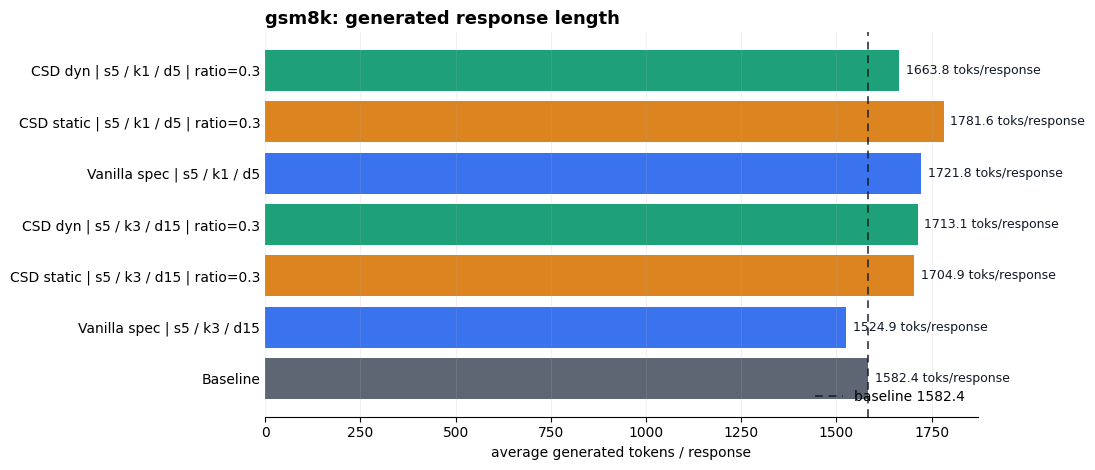

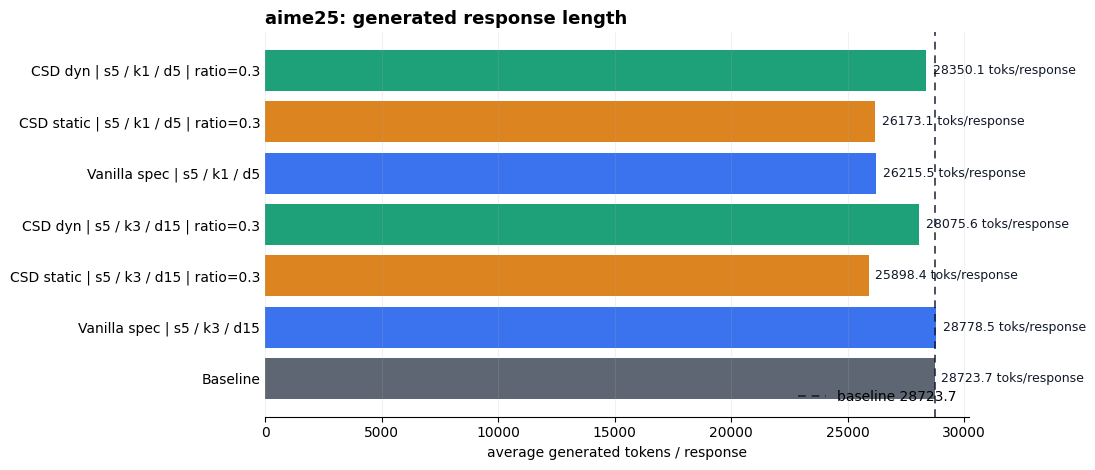

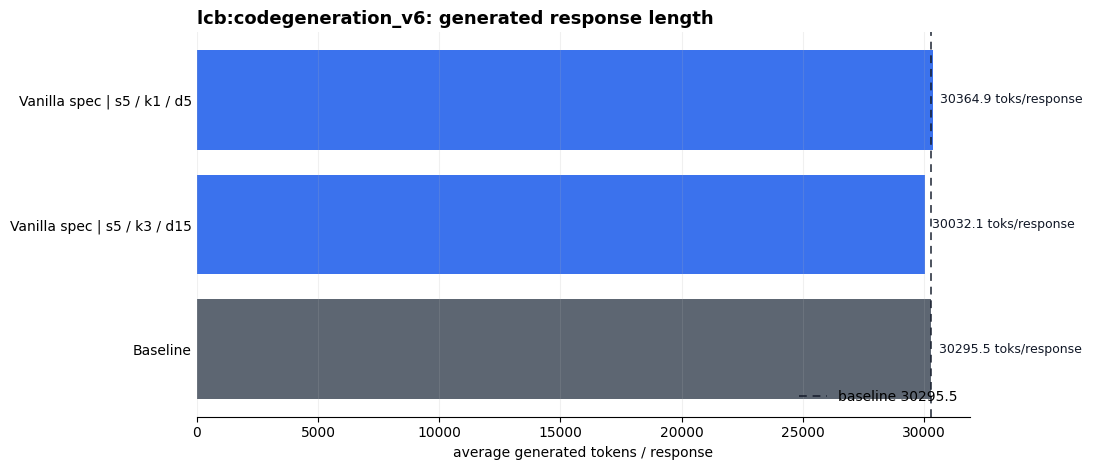

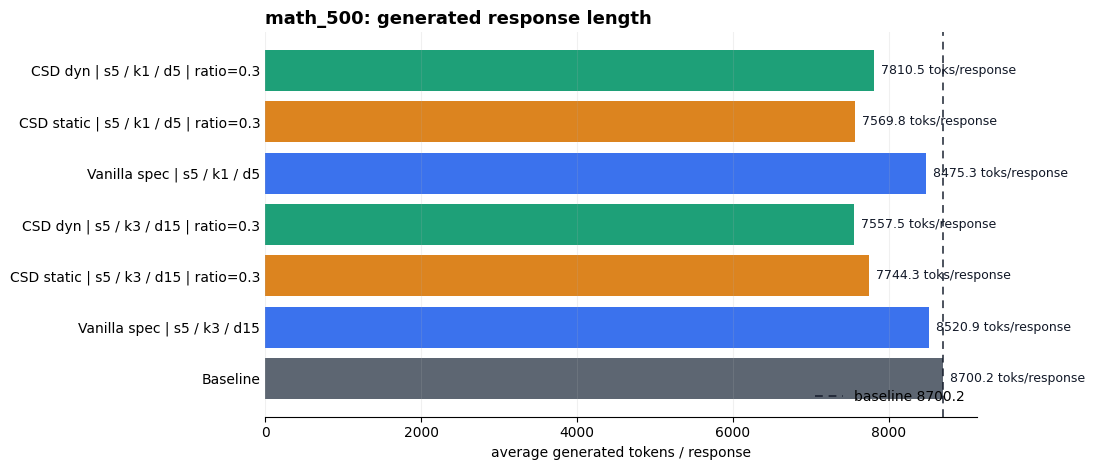

In [39]:
length_cols = [
    'line', 'base_task', 'variant', 'spec_shape', 'csd_prob_ratio', 'accuracy',
    'avg_prompt_tokens', 'avg_completion_tokens', 'total_prompt_tokens', 'total_completion_tokens',
    'total_requests', 'latency_sec', 'throughput', 'missing_performance',
]
response_length_table = (
    cmp_df[length_cols]
    .copy()
    .sort_values(['base_task', 'spec_shape', 'variant', 'csd_prob_ratio', 'line'])
)
response_length_format = {
    'accuracy': '{:.6f}',
    'avg_prompt_tokens': '{:.1f}',
    'avg_completion_tokens': '{:.1f}',
    'total_prompt_tokens': '{:.0f}',
    'total_completion_tokens': '{:.0f}',
    'total_requests': '{:.0f}',
    'latency_sec': '{:.1f}',
    'throughput': '{:.1f}',
}

print('Generated response length by task and decoding variant')
display(response_length_table.style.format(response_length_format, na_rep=''))

plot_lengths = plot_df.dropna(subset=['avg_completion_tokens']).copy()
if plot_lengths.empty:
    print('No non-null generated response length rows to plot.')
else:
    for task in task_order:
        sub = plot_lengths[plot_lengths['base_task'] == task].sort_values('line')
        if sub.empty:
            print(f'{task}: no non-null generated response length rows to plot.')
            continue

        fig, ax = plt.subplots(figsize=(11, max(4.8, 0.45 * len(sub))))
        colors = [VARIANT_COLORS.get(variant, '#6b7280') for variant in sub['variant']]
        values = sub['avg_completion_tokens']
        offset = max(float(values.max()) * 0.01, 1.0)
        bars = ax.barh(sub['plot_label'], values, color=colors, alpha=0.9)

        baseline_value = sub.loc[sub['variant'] == 'baseline', 'avg_completion_tokens']
        if not baseline_value.empty and pd.notna(baseline_value.iloc[-1]):
            baseline_len = baseline_value.iloc[-1]
            ax.axvline(
                baseline_len,
                linestyle=(0, (4, 3)),
                linewidth=1.4,
                color='#111827',
                alpha=0.75,
                label=f'baseline {baseline_len:.1f}',
            )

        for bar, value in zip(bars, values):
            if pd.isna(value):
                continue
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height() / 2,
                f'{value:.1f} toks/response',
                va='center',
                ha='left',
                fontsize=9,
                color='#111827',
            )

        ax.set_title(f'{task}: generated response length', fontsize=13, fontweight='bold', loc='left')
        ax.set_xlabel('average generated tokens / response')
        ax.grid(axis='x', alpha=0.18)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='y', length=0)
        if not baseline_value.empty:
            ax.legend(frameon=False, loc='lower right')
        plt.tight_layout()
        save_figure(fig, f'response_length_{task}')

## Per-dataset CSD behavior

These figures focus on CSD rows only, with CSD-static and CSD-dyn drawn as separate series. The left panel compares CSD accuracy against baseline and vanilla references; the right panel shows semantic accepts per lookup hit.

Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/csd_behavior_gsm8k.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/csd_behavior_aime25.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/csd_behavior_lcb-codegeneration_v6.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/csd_behavior_math_500.png
CSD table for spec_shape=steps5_topk1_draft5


,line,base_task,variant,spec_shape,csd_freq_threshold,csd_prob_ratio,accuracy,accuracy_delta_vs_baseline,accuracy_delta_vs_vanilla,throughput,throughput_vs_baseline_text,spec_success_rate,csd_force_per_hit,csd_force_per_verify,csd_lookup_hit_ct,csd_forced_accept_ct,csd_delta_pair_ct,missing_spec_metrics
25,26,aime25,csd-dyn,steps5_topk1_draft5,6,0.300000,0.800000,-0.133333,-0.100000,1659.4,1.34x vs baseline,0.7392,0.6020,4.96,1492173,898334,2575054,False
21,22,aime25,csd-static,steps5_topk1_draft5,6,0.300000,0.900000,-0.033333,+0.000000,1899.4,1.53x vs baseline,0.6964,0.5941,4.71,1389765,825727,0,False
24,25,gsm8k,csd-dyn,steps5_topk1_draft5,6,0.300000,0.920394,+0.001516,-0.002275,2348.1,0.95x vs baseline,0.7795,0.3777,68.67,81464417,30771676,160290299,False
20,21,gsm8k,csd-static,steps5_topk1_draft5,6,0.300000,0.915845,-0.003033,-0.006824,2640.7,1.07x vs baseline,0.7839,0.3721,52.00,66750323,24838336,0,False
26,27,lcb:codegeneration_v6,csd-dyn,steps5_topk1_draft5,6,0.300000,0.645714,-0.142857,-0.074286,0.0,0.00x vs baseline,,,,,,,True
22,23,lcb:codegeneration_v6,csd-static,steps5_topk1_draft5,6,0.300000,0.714286,-0.074285,-0.005714,0.0,0.00x vs baseline,,,,,,,True
27,28,math_500,csd-dyn,steps5_topk1_draft5,6,0.300000,0.832000,-0.022000,+0.008000,2317.7,1.01x vs baseline,0.7527,0.5864,75.83,106011103,62169748,172911874,False
23,24,math_500,csd-static,steps5_topk1_draft5,6,0.300000,0.834000,-0.020000,+0.010000,3218.1,1.40x vs baseline,0.6978,0.5899,63.52,90800851,53560944,0,False


CSD table for spec_shape=steps5_topk3_draft15


,line,base_task,variant,spec_shape,csd_freq_threshold,csd_prob_ratio,accuracy,accuracy_delta_vs_baseline,accuracy_delta_vs_vanilla,throughput,throughput_vs_baseline_text,spec_success_rate,csd_force_per_hit,csd_force_per_verify,csd_lookup_hit_ct,csd_forced_accept_ct,csd_delta_pair_ct,missing_spec_metrics
13,14,aime25,csd-dyn,steps5_topk3_draft15,6,0.300000,0.833333,-0.100000,-0.066667,1287.4,1.04x vs baseline,0.8643,0.5342,5.90,1747915,933671,3370137,False
9,10,aime25,csd-static,steps5_topk3_draft15,6,0.300000,0.933333,+0.000000,+0.033333,1475.3,1.19x vs baseline,0.8320,0.5113,5.36,1579740,807645,0,False
12,13,gsm8k,csd-dyn,steps5_topk3_draft15,6,0.300000,0.930250,+0.011372,+0.008339,1866.4,0.76x vs baseline,0.9011,0.3303,83.04,103178657,34082049,221876955,False
8,9,gsm8k,csd-static,steps5_topk3_draft15,6,0.300000,0.914329,-0.004549,-0.007582,2038.7,0.83x vs baseline,0.8958,0.3267,65.14,81842472,26736332,0,False
14,15,lcb:codegeneration_v6,csd-dyn,steps5_topk3_draft15,6,0.300000,0.645714,-0.142857,-0.097143,0.0,0.00x vs baseline,,,,,,,True
10,11,lcb:codegeneration_v6,csd-static,steps5_topk3_draft15,6,0.300000,0.720000,-0.068571,-0.022857,0.0,0.00x vs baseline,,,,,,,True
15,16,math_500,csd-dyn,steps5_topk3_draft15,6,0.300000,0.840000,-0.014000,-0.012000,1726.7,0.75x vs baseline,0.8642,0.5169,96.02,131913489,68192289,233328199,False
11,12,math_500,csd-static,steps5_topk3_draft15,6,0.300000,0.846000,-0.008000,-0.006000,2107.9,0.91x vs baseline,0.8311,0.5171,74.06,107573369,55627827,0,False


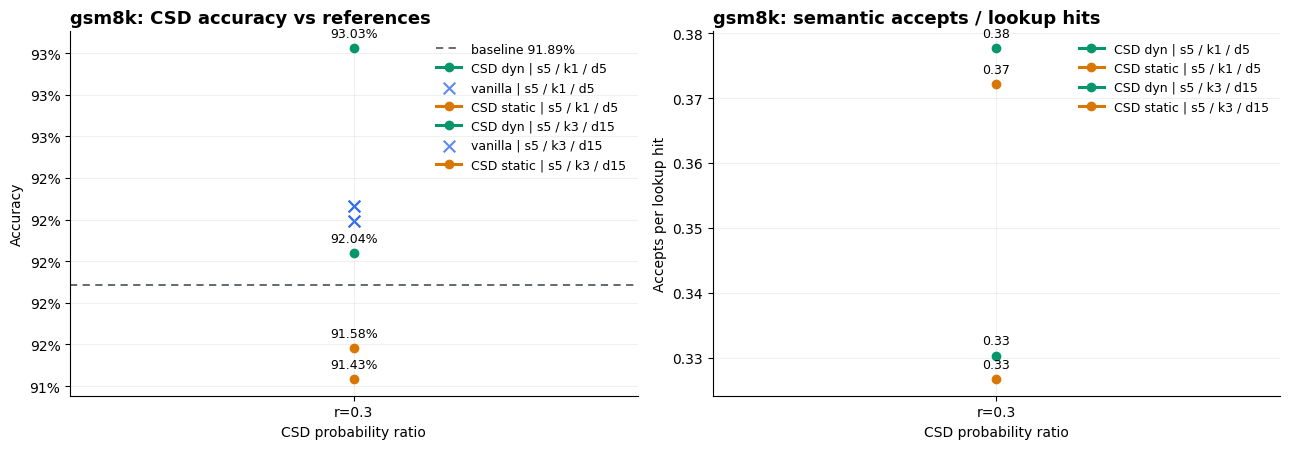

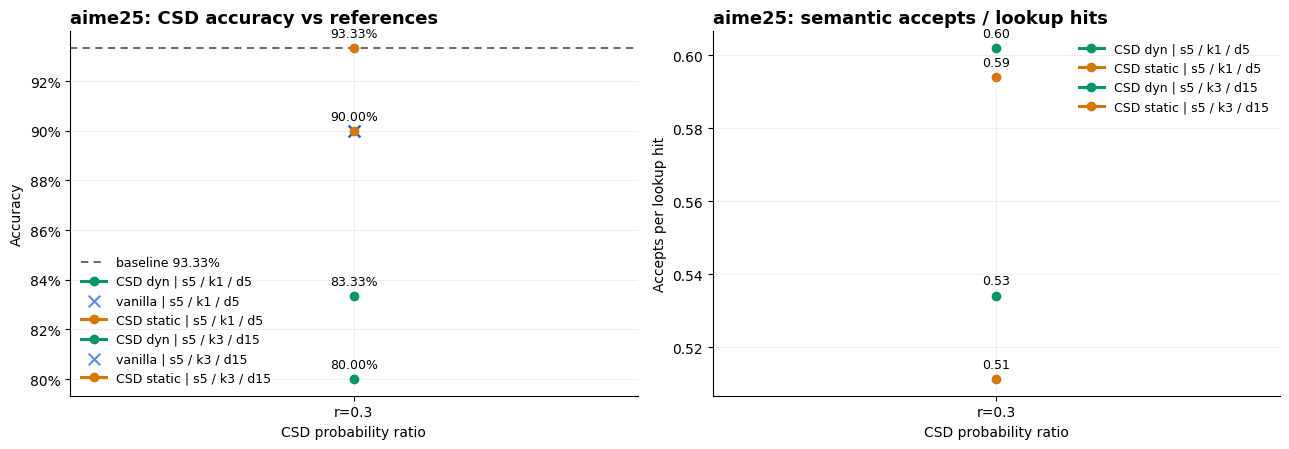

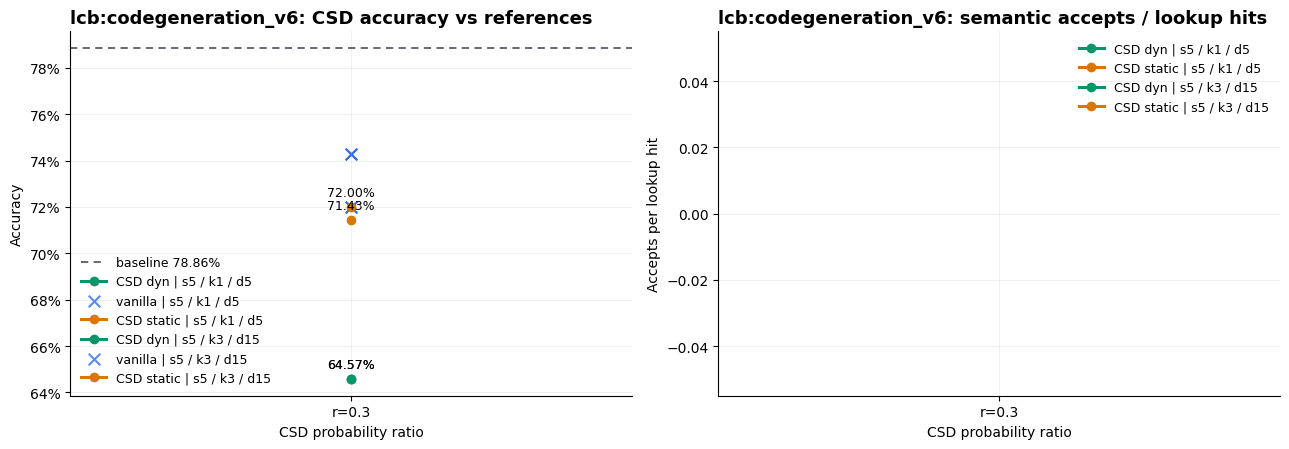

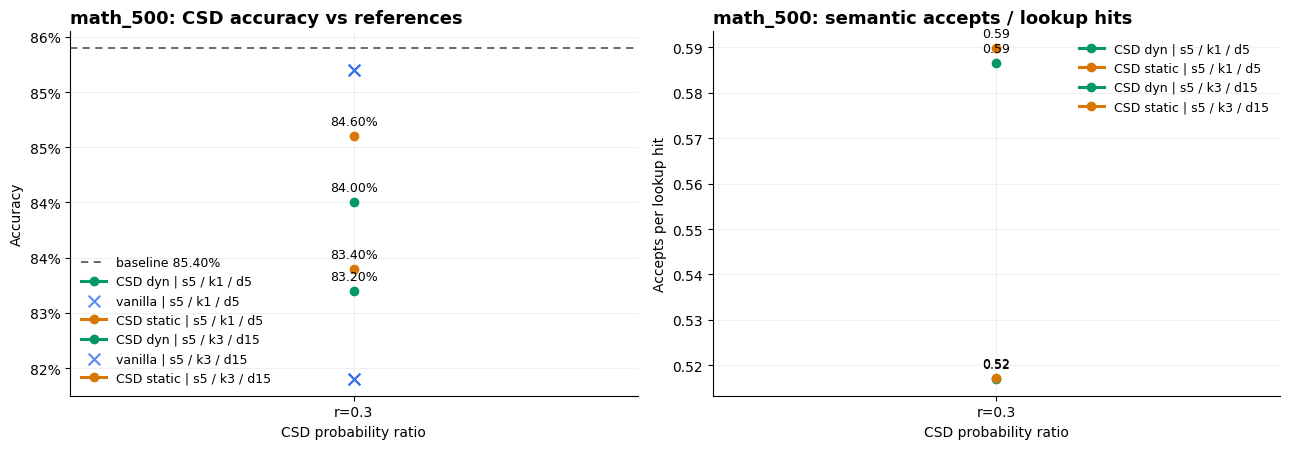

In [40]:
csd_df = cmp_df[cmp_df['mode'] == 'csd'].copy()


def spec_display_name(spec_shape):
    return pretty_spec_shape(spec_shape)

if csd_df.empty:
    print('No CSD rows found.')
else:
    for task in task_order:
        task_csd = csd_df[csd_df['base_task'] == task].sort_values(['spec_shape', 'variant', 'csd_prob_ratio', 'line'])
        if task_csd.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
        baseline_value = task_csd['baseline_accuracy'].dropna()
        if not baseline_value.empty:
            axes[0].axhline(
                baseline_value.iloc[-1],
                linestyle=(0, (4, 3)),
                linewidth=1.3,
                color='#111827',
                alpha=0.7,
                label=f'baseline {baseline_value.iloc[-1]:.2%}',
            )

        for (spec_shape, variant), sub in task_csd.groupby(['spec_shape', 'variant'], sort=True):
            sub = sub.sort_values(['csd_prob_ratio', 'line'])
            x = range(len(sub))
            label = f'{VARIANT_LABELS.get(variant, variant)} | {spec_display_name(spec_shape)}'
            color = VARIANT_COLORS.get(variant, '#6b7280')
            axes[0].plot(x, sub['accuracy'], marker='o', linewidth=2.2, color=color, label=label)
            axes[1].plot(x, sub['csd_force_per_hit'], marker='o', linewidth=2.2, color=color, label=label)

            vanilla_accuracy = sub['vanilla_accuracy'].dropna()
            if not vanilla_accuracy.empty:
                axes[0].scatter(
                    list(x),
                    sub['vanilla_accuracy'],
                    marker='x',
                    s=70,
                    color='#2563eb',
                    alpha=0.75,
                    label=f'vanilla | {spec_display_name(spec_shape)}',
                )

            ratio_labels = []
            for j, (_, row) in enumerate(sub.iterrows()):
                ratio_labels.append(f"r={row['csd_prob_ratio']:g}")
                if pd.notna(row['accuracy']):
                    axes[0].annotate(
                        f"{row['accuracy']:.2%}",
                        (j, row['accuracy']),
                        textcoords='offset points',
                        xytext=(0, 8),
                        ha='center',
                        fontsize=9,
                    )
                if pd.notna(row['csd_force_per_hit']):
                    axes[1].annotate(
                        f"{row['csd_force_per_hit']:.2f}",
                        (j, row['csd_force_per_hit']),
                        textcoords='offset points',
                        xytext=(0, 8),
                        ha='center',
                        fontsize=9,
                    )
            axes[0].set_xticks(list(x), ratio_labels)
            axes[1].set_xticks(list(x), ratio_labels)

        axes[0].set_title(f'{task}: CSD accuracy vs references', fontsize=13, fontweight='bold', loc='left')
        axes[0].set_ylabel('Accuracy')
        axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        axes[1].set_title(f'{task}: semantic accepts / lookup hits', fontsize=13, fontweight='bold', loc='left')
        axes[1].set_ylabel('Accepts per lookup hit')
        for ax in axes:
            ax.set_xlabel('CSD probability ratio')
            ax.grid(alpha=0.18)
            ax.spines[['top', 'right']].set_visible(False)
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), frameon=False, fontsize=9)
        plt.tight_layout()
        save_figure(fig, f'csd_behavior_{task}')

csd_table_cols = [
    'line', 'base_task', 'variant', 'spec_shape', 'csd_freq_threshold', 'csd_prob_ratio',
    'accuracy', 'accuracy_delta_vs_baseline', 'accuracy_delta_vs_vanilla', 'throughput',
    'throughput_vs_baseline_text', 'spec_success_rate', 'csd_force_per_hit', 'csd_force_per_verify',
    'csd_lookup_hit_ct', 'csd_forced_accept_ct', 'csd_delta_pair_ct', 'missing_spec_metrics'
]
for spec_shape, sub in csd_df.sort_values(['spec_shape', 'base_task', 'variant', 'csd_prob_ratio', 'line']).groupby('spec_shape'):
    print(f'CSD table for spec_shape={spec_shape}')
    display(sub[csd_table_cols].style.format({
        'accuracy': '{:.6f}',
        'accuracy_delta_vs_baseline': '{:+.6f}',
        'accuracy_delta_vs_vanilla': '{:+.6f}',
        'throughput': '{:.1f}',
        'spec_success_rate': '{:.4f}',
        'csd_force_per_hit': '{:.4f}',
        'csd_force_per_verify': '{:.2f}',
        'csd_lookup_hit_ct': '{:.0f}',
        'csd_forced_accept_ct': '{:.0f}',
        'csd_delta_pair_ct': '{:.0f}',
    }, na_rep=''))

## Speculative success-rate table

This section keeps vanilla, CSD-static, and CSD-dyn separate. Rows with missing speculative metrics are listed explicitly, which is why LCB may be absent from the non-null success-rate plots even though LCB accuracy rows are present above.

For the current compact rows, LCB has `throughput=0.0` and missing `spec_success_rate` / `accept_length`, so it cannot be used in charts that require speculative success-rate data. It remains visible in the accuracy/performance tables and in the missing-metrics table below.

Speculative success-rate rows, including CSD-static and CSD-dyn


,line,base_task,mode,variant,spec_shape,csd_prob_ratio,csd_dynamic_update,accuracy,throughput,accept_length,aggregate_accept_length,spec_success_rate,aggregate_spec_accept_rate,spec_output_token_saved_ratio,csd_force_per_hit,csd_lookup_hit_ct,csd_forced_accept_ct,missing_spec_metrics
0,26,aime25,csd,csd-dyn,steps5_topk1_draft5,0.300000,True,0.800000,1659.4,4.6288,4.6959,0.7392,0.7392,0.7871,0.6020,1492173,898334,False
1,22,aime25,csd,csd-static,steps5_topk1_draft5,0.300000,False,0.900000,1899.4,4.4712,4.4821,0.6964,0.6964,0.7769,0.5941,1389765,825727,False
2,18,aime25,vanilla,vanilla,steps5_topk1_draft5,0.010000,False,0.900000,1617.8,3.8298,3.7961,0.5592,0.5592,0.7366,,0,0,False
3,14,aime25,csd,csd-dyn,steps5_topk3_draft15,0.300000,True,0.833333,1287.4,5.2531,5.3213,0.8643,0.8643,0.8121,0.5342,1747915,933671,False
4,10,aime25,csd,csd-static,steps5_topk3_draft15,0.300000,False,0.933333,1475.3,5.1347,5.1600,0.8320,0.8320,0.8062,0.5113,1579740,807645,False
5,6,aime25,vanilla,vanilla,steps5_topk3_draft15,0.010000,False,0.900000,1359.4,4.6888,4.6854,0.7371,0.7371,0.7866,,0,0,False
6,25,gsm8k,csd,csd-dyn,steps5_topk1_draft5,0.300000,True,0.920394,2348.1,4.9453,4.8974,0.7795,0.7795,0.7960,0.3777,81464417,30771676,False
7,21,gsm8k,csd,csd-static,steps5_topk1_draft5,0.300000,False,0.915845,2640.7,4.8864,4.9194,0.7839,0.7839,0.7969,0.3721,66750323,24838336,False
8,17,gsm8k,vanilla,vanilla,steps5_topk1_draft5,0.010000,False,0.922669,2670.6,4.7058,4.6336,0.7267,0.7267,0.7843,,0,0,False
9,13,gsm8k,csd,csd-dyn,steps5_topk3_draft15,0.300000,True,0.930250,1866.4,5.5477,5.5055,0.9011,0.9011,0.8185,0.3303,103178657,34082049,False


Pivoted speculative success-rate table


,base_task,spec_shape,vanilla,csd-static,csd-dyn
0,aime25,steps5_topk1_draft5,0.5592,0.6964,0.7392
1,aime25,steps5_topk3_draft15,0.7371,0.8320,0.8643
2,gsm8k,steps5_topk1_draft5,0.7267,0.7839,0.7795
3,gsm8k,steps5_topk3_draft15,0.8548,0.8958,0.9011
4,lcb:codegeneration_v6,steps5_topk1_draft5,0.4721,,
5,lcb:codegeneration_v6,steps5_topk3_draft15,0.6579,,
6,math_500,steps5_topk1_draft5,0.5591,0.6978,0.7527
7,math_500,steps5_topk3_draft15,0.7294,0.8311,0.8642


Rows missing speculative success-rate metrics


,line,base_task,variant,spec_shape,accuracy,throughput,accept_length,spec_success_rate,missing_spec_metrics
12,27,lcb:codegeneration_v6,csd-dyn,steps5_topk1_draft5,0.645714,0.0,,,True
13,23,lcb:codegeneration_v6,csd-static,steps5_topk1_draft5,0.714286,0.0,,,True
14,19,lcb:codegeneration_v6,vanilla,steps5_topk1_draft5,0.720000,0.0,,,True
16,15,lcb:codegeneration_v6,csd-dyn,steps5_topk3_draft15,0.645714,0.0,,,True
17,11,lcb:codegeneration_v6,csd-static,steps5_topk3_draft15,0.720000,0.0,,,True
18,7,lcb:codegeneration_v6,vanilla,steps5_topk3_draft15,0.742857,0.0,,,True


Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/spec_success_rate_gsm8k.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/spec_success_rate_aime25.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/spec_success_rate_lcb-codegeneration_v6.png
Saved figure: /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures/spec_success_rate_math_500.png


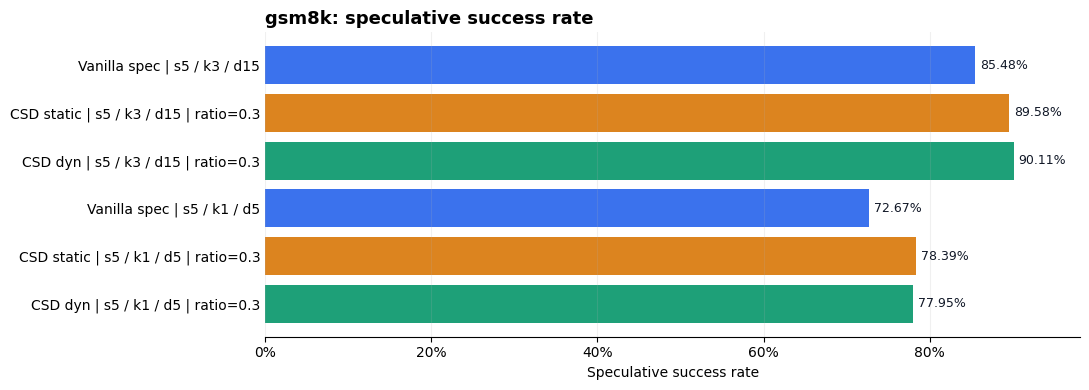

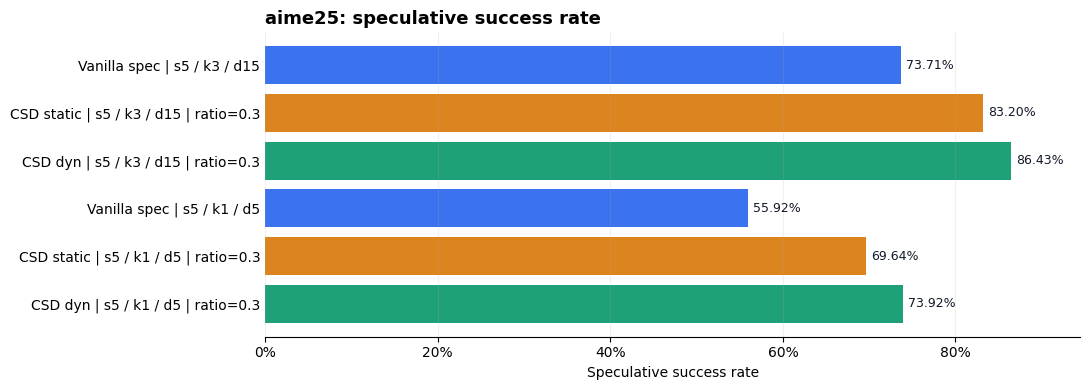

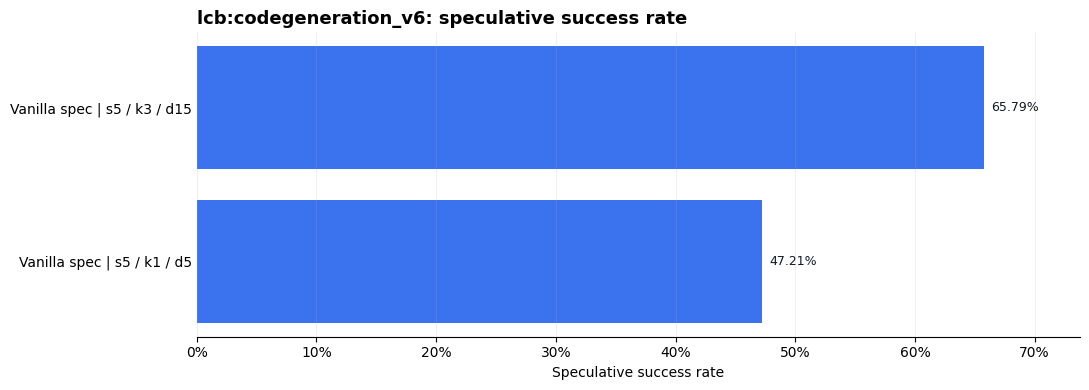

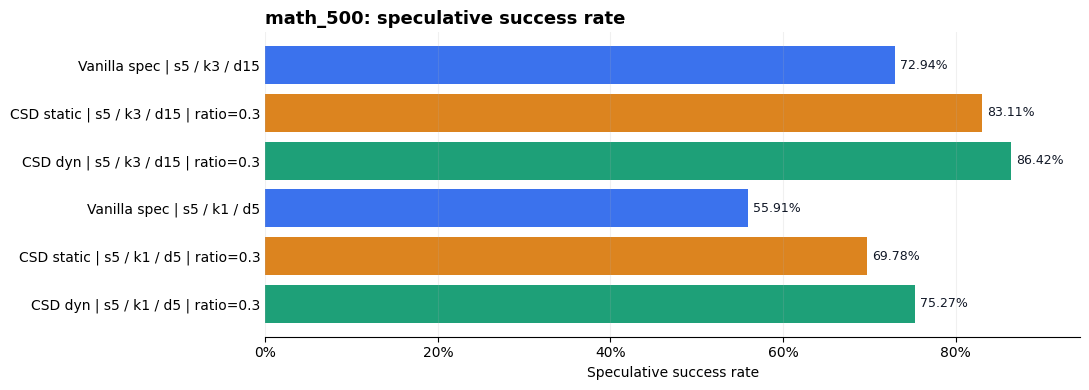

In [41]:
success_cols = [
    'line', 'base_task', 'mode', 'variant', 'spec_shape', 'csd_prob_ratio', 'csd_dynamic_update',
    'accuracy', 'throughput', 'accept_length', 'aggregate_accept_length', 'spec_success_rate',
    'aggregate_spec_accept_rate', 'spec_output_token_saved_ratio', 'csd_force_per_hit',
    'csd_lookup_hit_ct', 'csd_forced_accept_ct', 'missing_spec_metrics',
]
success_long = (
    cmp_df[cmp_df['variant'].isin(['vanilla', 'csd-static', 'csd-dyn'])]
    [success_cols]
    .sort_values(['base_task', 'spec_shape', 'variant', 'csd_prob_ratio', 'line'])
    .reset_index(drop=True)
)

success_format = {
    'accuracy': '{:.6f}',
    'throughput': '{:.1f}',
    'accept_length': '{:.4f}',
    'aggregate_accept_length': '{:.4f}',
    'spec_success_rate': '{:.4f}',
    'aggregate_spec_accept_rate': '{:.4f}',
    'spec_output_token_saved_ratio': '{:.4f}',
    'csd_force_per_hit': '{:.4f}',
    'csd_lookup_hit_ct': '{:.0f}',
    'csd_forced_accept_ct': '{:.0f}',
}

print('Speculative success-rate rows, including CSD-static and CSD-dyn')
display(success_long.style.format(success_format, na_rep=''))

success_rate_table = (
    success_long
    .pivot_table(
        index=['base_task', 'spec_shape'],
        columns='variant',
        values='spec_success_rate',
        aggfunc='last',
        dropna=False,
    )
    .reset_index()
)
success_rate_table.columns.name = None
for col in ['vanilla', 'csd-static', 'csd-dyn']:
    if col not in success_rate_table.columns:
        success_rate_table[col] = pd.NA
success_rate_table = success_rate_table[['base_task', 'spec_shape', 'vanilla', 'csd-static', 'csd-dyn']]
success_rate_table = success_rate_table.sort_values(['base_task', 'spec_shape']).reset_index(drop=True)

print('Pivoted speculative success-rate table')
display(success_rate_table.style.format({
    'vanilla': '{:.4f}',
    'csd-static': '{:.4f}',
    'csd-dyn': '{:.4f}',
}, na_rep=''))

missing_spec_table = success_long[success_long['missing_spec_metrics']].copy()
if missing_spec_table.empty:
    print('No speculative rows are missing success-rate metrics.')
else:
    print('Rows missing speculative success-rate metrics')
    display(missing_spec_table[[
        'line', 'base_task', 'variant', 'spec_shape', 'accuracy', 'throughput',
        'accept_length', 'spec_success_rate', 'missing_spec_metrics'
    ]].style.format({
        'accuracy': '{:.6f}',
        'throughput': '{:.1f}',
        'accept_length': '{:.4f}',
        'spec_success_rate': '{:.4f}',
    }, na_rep=''))

plot_success = success_long.dropna(subset=['spec_success_rate']).copy()
if plot_success.empty:
    print('No non-null speculative success-rate rows to plot.')
else:
    for task in task_order:
        sub = plot_success[plot_success['base_task'] == task].sort_values(['spec_shape', 'variant', 'line'])
        if sub.empty:
            print(f'{task}: no non-null speculative success-rate rows to plot.')
            continue
        sub = sub.assign(plot_label=sub.apply(pretty_config_label, axis=1))
        fig, ax = plt.subplots(figsize=(11, max(4, 0.42 * len(sub))))
        colors = [VARIANT_COLORS.get(variant, '#6b7280') for variant in sub['variant']]
        bars = ax.barh(sub['plot_label'], sub['spec_success_rate'], color=colors, alpha=0.9)
        for bar, value in zip(bars, sub['spec_success_rate']):
            ax.text(
                value + 0.006,
                bar.get_y() + bar.get_height() / 2,
                f'{value:.2%}',
                va='center',
                ha='left',
                fontsize=9,
                color='#111827',
            )
        ax.set_xlim(0, min(1.05, max(0.1, sub['spec_success_rate'].max() + 0.08)))
        ax.set_title(f'{task}: speculative success rate', fontsize=13, fontweight='bold', loc='left')
        ax.set_xlabel('Speculative success rate')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.grid(axis='x', alpha=0.18)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='y', length=0)
        plt.tight_layout()
        save_figure(fig, f'spec_success_rate_{task}')

In [42]:
EXPORT_DIR = RESULT_JSONL.parent / 'analysis_tables'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(EXPORT_DIR / 'flattened_results.csv', index=False)
compare_table.to_csv(EXPORT_DIR / 'comparison_table.csv', index=False)
perf_table.to_csv(EXPORT_DIR / 'performance_table.csv', index=False)
response_length_table.to_csv(EXPORT_DIR / 'response_length_table.csv', index=False)
best_accuracy.to_csv(EXPORT_DIR / 'best_accuracy_top3.csv', index=False)
best_throughput.to_csv(EXPORT_DIR / 'best_throughput_top3.csv', index=False)
success_long.to_csv(EXPORT_DIR / 'spec_success_rate_long.csv', index=False)
success_rate_table.to_csv(EXPORT_DIR / 'spec_success_rate_table.csv', index=False)
missing_spec_table.to_csv(EXPORT_DIR / 'missing_spec_metrics_rows.csv', index=False)
print(f'Wrote CSV summaries to {EXPORT_DIR}')
print(f'Wrote PNG figures to {FIGURE_DIR}')

Wrote CSV summaries to /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_tables
Wrote PNG figures to /home/zhouxuwen/sglang/benchmark/csd/runs/lighteval/results/analysis_figures
